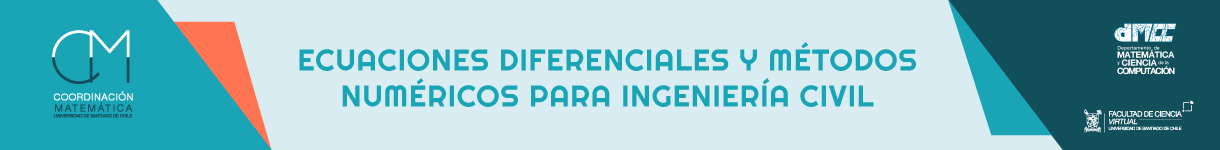


#**Semana 4**

- Aplicaciones de EDO's de primer orden.
- Resolución de problemas que involucran EDO's de primer orden utilizando aproximaciones numéricas y métodos analíticos mediante Python.

**ACTIVIDAD:** En parejas, lean atentamente cada uno de los siguientes problemas y proponga una solución utilizando los comandos vistos en clases.

Realice un desarrollo de manera coherente y ordenada.

**COMENZAR POR LOS EJERCICIOS: 1, 2, 7 y 3.**

In [31]:
#Importación de librerías

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing(use_latex='mathjax')

#Métodos numéricos
#Método de Euler
def Euler(f,x0,xn,y0,n):              #Nuestra función se llama Euler y sus datos de entrada son f,x0,xn,y0,n
    X = np.linspace(x0,xn,n+1)        #Recordemos que para tener n segmentos necesitamos n+1 puntos
    Y = np.empty(n + 1)               #Crea una lista "vacía" de longitud n
    Y[0] = y0
    h=(xn-x0)/n
    for i in range(n):                #Recordemos que el método se ejecuta para i=0,1,2,...,n-1
        Y[i+1] = Y[i] + h*f(X[i],Y[i])
    return Y

#Método RK4
def RK4(f, x0, xn, y0, n):
    X = np.linspace(x0,xn,n+1)
    Y = np.empty(n + 1)
    Y[0] = y0
    h = (xn-x0)/n
    for i in range(n):
        K1=h*f(X[i],Y[i])
        K2=h*f(X[i]+h/2,Y[i]+(1/2)*K1)
        K3=h*f(X[i]+h/2,Y[i]+(1/2)*K2)
        K4=h*f(X[i]+h,Y[i]+K3)
        Y[i+1] = Y[i] +(1/6)*(K1+2*K2+2*K3+K4)
    return Y

def graficar_campo_direcciones(f, x_lim, y_lim, titulo, equilibrios=[], x_label='x', y_label='y'):
    x = np.linspace(x_lim[0], x_lim[1], 35)
    y = np.linspace(y_lim[0], y_lim[1], 35)
    X, Y = np.meshgrid(x, y)
    
    U = 1
    V = f(X, Y)
    N = np.sqrt(U**2 + V**2)
    U, V = U/N, V/N
    
    plt.figure(figsize=(8, 5))
    plt.quiver(X, Y, U, V, color='teal', alpha=0.6)
    
    for eq in equilibrios:
        plt.axhline(eq, color='red', linestyle='--', lw=2, label=f'Equilibrio {y_label}={eq}')
        
    plt.title(titulo)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if equilibrios:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#Ejercicio 1

El circuito eléctrico más sencillo está dado por

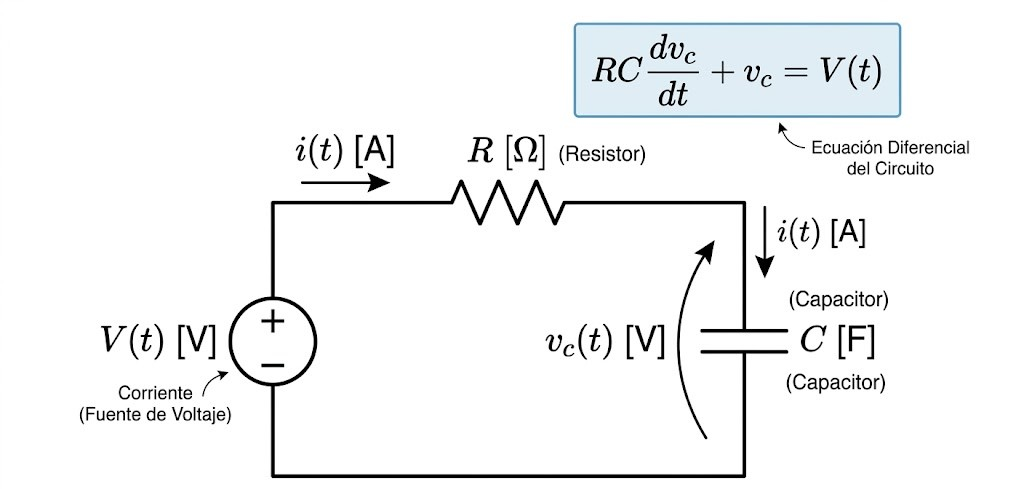

el circuito contiene un capacitor, un resistor y una fuente de voltaje. El comportamiento del resistor es definido por una constante positiva $R$ (la resistencia) medida en Ohms $[\Omega]$, el del capacitor por una constante positiva $C$ (la capacitancia) medida en Faraday $[F]$. El voltaje de entrada a través de la fuente de voltage en un tiempo dado $t$ se denota por $V(t)$ medida en Volts $[V]$. Esta fuente de voltaje puede ser una fuente constante como la de una batería, o puede ser variable.

Las variables que determinan el comportamiento del circuito en un tiempo particular $t$ son la corriente $i(t)$ y el voltaje a través del capacitor $v_c(t)$. La teoría de circuitos eléctricos establece que el voltaje $v_c$ satisface la ecuación diferencial
$$ RC \frac{d v_c}{dt} + v_c = V(t) $$

Suponga que un determinado circuito $R=2 [\Omega]$, $C=0.2 [F]$.

* a) Reescriba la EDO con los datos entregados en su forma $ v_c ' = f(t, v_c) $ identificando las variables independiente y dependiente.

* b) Suponga que el voltaje de entrada es nulo $V(t)=0 [V]$, construya un campo de direcciones asociado y describa el comportamiento de las soluciones conforme $t \to \infty$.

* c) Suponga esta vez que el voltaje de entrada es constante $V(t)=20 [V]$. Determine soluciones de equilibrio.

* d) Repita el análisis hecho en b) con $V(t)=20 [V]$.

a) Reescribir la EDO la ecuación es:$$RC \frac{dv_c}{dt} + v_c = V(t)$$Sustituyendo $R=2$ y $C=0.2$, tenemos $RC = 0.4$. Despejando la derivada:$$0.4 v_c' + v_c = V(t) \implies v_c' = \frac{V(t) - v_c}{0.4} = 2.5 V(t) - 2.5 v_c$$Variable independiente: $t$ (tiempo).Variable dependiente: $v_c$ (voltaje del capacitor).b) Comportamiento con $V(t) = 0$La ecuación queda $v_c' = -2.5 v_c$.Como la tasa de cambio es proporcional y opuesta al valor actual de $v_c$, las soluciones decaen exponencialmente hacia el equilibrio. Conforme $t \to \infty$, $v_c(t) \to 0$.c) Soluciones de equilibrio con $V(t) = 20$La ecuación queda $v_c' = 50 - 2.5 v_c$.Para encontrar el equilibrio, igualamos la derivada a cero:$$50 - 2.5 v_c = 0 \implies 2.5 v_c = 50 \implies v_c = 20 [V]$$La única solución de equilibrio es $v_c = 20$.  
d) Comportamiento con $V(t) = 20$ Independientemente del voltaje inicial en el capacitor, conforme el tiempo avance, el capacitor se cargará (o descargará) hasta igualar el voltaje de la fuente. Por tanto, cuando $t \to \infty$, $v_c(t) \to 20$.

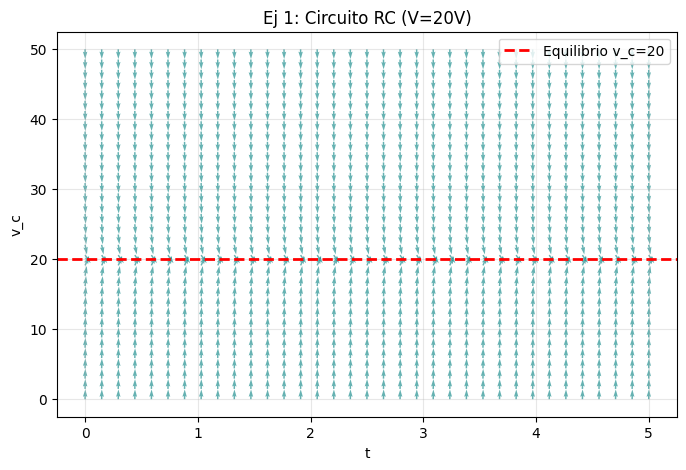

In [33]:
f1 = lambda t, vc: 50 - 2.5 * vc
graficar_campo_direcciones(f1, [0, 5], [0, 50], "Ej 1: Circuito RC (V=20V)", equilibrios=[20], x_label='t', y_label='v_c')

#Ejercicio 2

La siguiente ecuación diferencial
$$ y' = e^{-x^2-y^2} \ln|x| $$
es **separable** y su solución general puede ser encontrada al calcular:
$$ \int e^{y^2}  dy = \int e^{-x^2} \ln|x| dx. $$
Sin embargo, estas integrales no son calculables mediante métodos tradicionales. A pesar de lo anterior, hemos aprendido en este curso que es posible estudiar el comportamiento de las soluciones de manera numérica. Para ello considere el PVI:

$$  y'=  e^{-x^2-y^2} \ln|x| \quad ; \quad y(2) = 4$$

* a) Utilizando el método de Euler, determine una aproximación de $y(10)$ para:
    
    * a.1) Cantidad de iteraciones $n=300$
    * a.2) Paso $h=0,1$

* b)  Hemos aproximado $y(10)$ mediante la función error y la función hipergeométrica generalizada; suponga que el resultado que hemos obtenido en nuestra apoximación corresponde a:

$$ y(10) \approx 0,7213487756160880 $$

Determine el error entre esta aproximación y las aproximaciones que calculó mediante el método de Euler.

In [3]:
def f(x, y):
    return np.exp(-x**2 - y**2) * np.log(np.abs(x))

x0, xn, y0 = 2, 10, 4
valor_exacto_aprox = 0.7213487756160880

# a.1) n = 300
Y_300 = Euler(f, x0, xn, y0, 300)
print(f"Aproximación con n=300: y(10) ≈ {Y_300[-1]}")

# a.2) h = 0.1 -> n = (10-2)/0.1 = 80
Y_80 = Euler(f, x0, xn, y0, 80)
print(f"Aproximación con h=0.1 (n=80): y(10) ≈ {Y_80[-1]}")

# b) Error
error_300 = abs(valor_exacto_aprox - Y_300[-1])
error_80 = abs(valor_exacto_aprox - Y_80[-1])
print(f"Error con n=300: {error_300}")
print(f"Error con h=0.1: {error_80}")

Aproximación con n=300: y(10) ≈ 4.000000000387397
Aproximación con h=0.1 (n=80): y(10) ≈ 4.000000000443405
Error con n=300: 3.2786512247713087
Error con h=0.1: 3.278651224827317


#Ejercicio 3

La EDO autónoma

$$m \frac{dy}{dt} = mg − ky^2$$

modela la velocidad $y(t)$ de un cuerpo de masa $m$ (en kg) que está cayendo bajo la influencia de la gravedad. Debido a que el término $–ky^2$ representa la resistencia del aire, la velocidad de un cuerpo que cae de una gran altura no aumenta sin límite conforme pasa el tiempo $t$.

Suponga que el cuerpo tiene masa 2 $[kg]$ y $k = g$ donde $g = 9, 8 \left[ \frac{m}{s^2} \right]$.

* (a) Construya un campo de direcciones para la EDO autónoma.
* (b) Determine y clasifique los puntos de equilibrio en atractor, repulsor o nodo.
* (c) Utilice la información anterior para encontrar la velocidad límite conforme $t \to \infty$.

La EDO es: $m y' = mg - ky^2 \implies 2y' = 2(9.8) - 9.8y^2 \implies y' = 9.8 - 4.9y^2$    
b) Puntos de equilibrio:Haciendo $y' = 0$:$$9.8 - 4.9y^2 = 0 \implies y^2 = 2 \implies y = \pm \sqrt{2}$$  Clasificación:Evaluamos la derivada de $f(y) = 9.8 - 4.9y^2$, que es $f'(y) = -9.8y$.  
Para $y = \sqrt{2}$: $f'(\sqrt{2}) < 0 \implies$ Atractor (Estable).Para $y = -\sqrt{2}$: $f'(-\sqrt{2}) > 0 \implies$ Repulsor (Inestable).  

c) Velocidad límite:Conforme un cuerpo cae ($t \to \infty$), su velocidad no superará ni caerá al infinito, sino que tenderá al punto de equilibrio atractor. Por ende, la velocidad límite es $y \to \sqrt{2} \approx 1.41 \text{ m/s}$. 

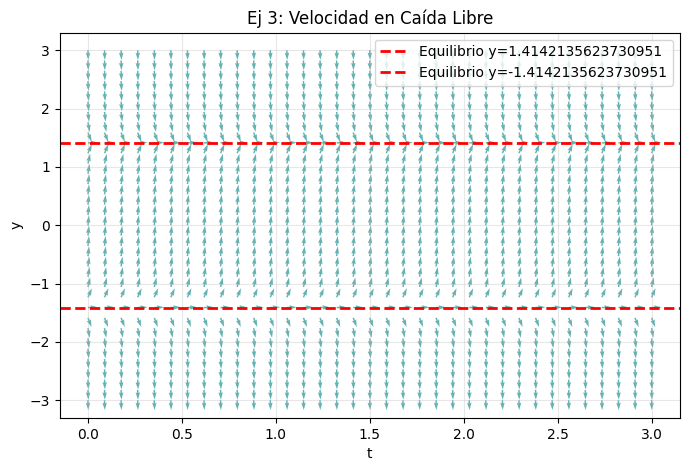

In [34]:
f3 = lambda t, y: 9.8 - 4.9 * y**2
graficar_campo_direcciones(f3, [0, 3], [-3, 3], "Ej 3: Velocidad en Caída Libre", equilibrios=[np.sqrt(2), -np.sqrt(2)], x_label='t', y_label='y')

#Ejercicio 4

Cuando se combinan ciertas clases de reacciones químicas, la razón con la que se forman los nuevos componentes se modela por la ecuación diferencial autónoma:

$$\frac{dx}{dt} = k[x^2 − (\alpha  + \beta)x + \alpha \beta],$$

donde $k > 0$ es una constante de proporcionalidad, $0 < \alpha < \beta$, y $x(t)$ denota el número de gramos del nuevo componente al tiempo $t$. Considere el caso en que $k = \frac{3}{2},$  $\alpha = 2$ y $\beta = 5$.

* (a) Construya un campo de direcciones para la EDO autónoma.
* (b) Determine y clasifique los puntos de equilibrio en atractor, repulsor o nodo.
* (c) Utilizando la información anterior, prediga el comportamiento de $x(t)$ para diferentes condiciones iniciales $x(0) = x_0$ conforme $t \to \infty$. Relacione este resultado con el contexto del problema.

La EDO es: $x' = 1.5 [x^2 - 7x + 10]$  
Factorizando: $x' = 1.5(x-2)(x-5)$    
b) Puntos de equilibrio:Igualando a 0: $x_1 = 2$ y $x_2 = 5$.  
- Clasificación:$f'(x) = 1.5(2x - 7)$ .  
- Para $x = 2$: $f'(2) = 1.5(-3) < 0 \implies$ Atractor (Estable).  
- Para $x = 5$: $f'(5) = 1.5(3) > 0 \implies$ Repulsor (Inestable).    

c) Predicción del comportamiento ($t \to \infty$):Si $x(0) < 5$, entonces $x(t) \to 2$.Si $x(0) = 5$, entonces $x(t) \to 5$.Si $x(0) > 5$, entonces $x(t) \to \infty$.  
Contexto: Si se mezclan suficientes gramos inicialmente (más de 5), la reacción crea gramos sin límite (o hasta que se acaben los reactivos originales, límite del modelo). Si hay menos de 5 gramos, el compuesto se estabilizará en 2 gramos.

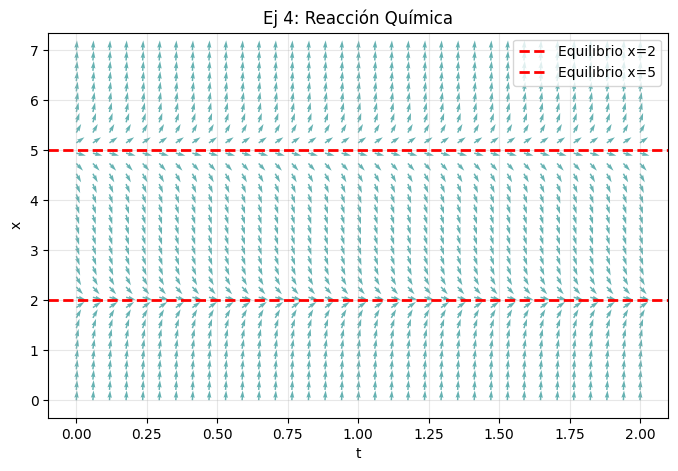

In [35]:
f4 = lambda t, x: 1.5 * (x - 2) * (x - 5)
graficar_campo_direcciones(f4, [0, 2], [0, 7], "Ej 4: Reacción Química", equilibrios=[2, 5], x_label='t', y_label='x')

#Ejercicio 5

Considere la ecuación diferencial
$$ y'=2xy^2 $$

* (a) Resuelva la EDO a través de variables separabales.
* (b) Verifique que $y=0$ también es solución de la EDO y que no pertenece a la familia de soluciones encontrada en a) ¿Contradice esto el teorema de existencia y unicidad?
* (c) Construya un campo de direcciones asociado a la EDO.
* (d) Utilizando un ciclo `for`, grafique al menos 10 soluciones particulares sobre el campo de direcciones y compruebe que los resultados en (a) son correctos.

a) Resolver $y' = 2xy^2$:$$\frac{dy}{y^2} = 2x \, dx \implies \int y^{-2} dy = \int 2x \, dx \implies -\frac{1}{y} = x^2 + C \implies y(x) = \frac{-1}{x^2 + C}$$  

b) Verificar $y=0$: Si $y=0$, $y' = 0$.   
- Al reemplazar en la EDO: $0 = 2x(0)^2$, se cumple.  Sin embargo, no existe ningún valor de constante $C$ finito que haga que $\frac{-1}{x^2 + C} = 0$.  
- ¿Contradice el teorema? No. El teorema de existencia y unicidad se cumple localmente. 
- La solución $y=0$ es una "solución singular" o envolvente y el teorema asegura que por cada condición inicial pasa una única curva, lo cual sigue siendo cierto.

d) Gráfico del campo y las soluciones con Python:

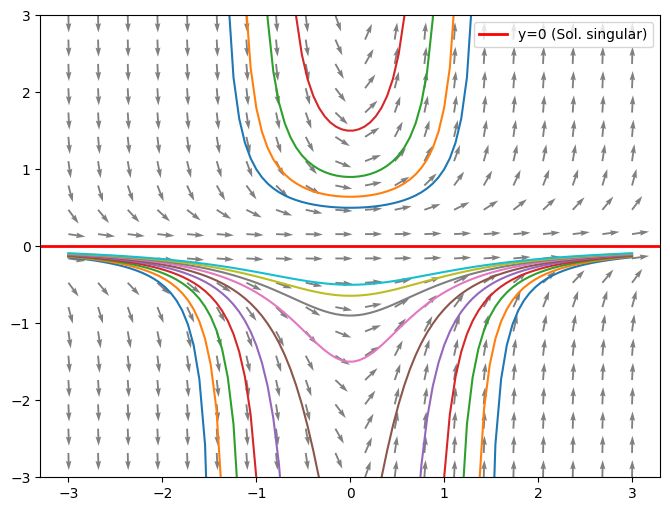

In [4]:
x, y = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
u = 1
v = 2 * x * y**2
# Normalizar vectores para el campo de direcciones
N = np.sqrt(u**2 + v**2)
u, v = u/N, v/N

plt.figure(figsize=(8, 6))
plt.quiver(x, y, u, v, color='gray')

X_sol = np.linspace(-3, 3, 100)
for C in np.linspace(-2, 2, 10):
    # Evitar singularidades dividiendo por casi cero
    Y_sol = -1 / (X_sol**2 + C)
    Y_sol[np.abs(X_sol**2 + C) < 0.05] = np.nan 
    plt.plot(X_sol, Y_sol)

plt.axhline(0, color='red', lw=2, label='y=0 (Sol. singular)')
plt.ylim(-3, 3)
plt.legend()
plt.show()

#Ejercicio 6

La siguiente ecuación diferencial
$$y' = e^{y^2}(1-y^2)$$
es **separable** y **autónoma** y su solución general puede ser encontrada integrando
$$\int \frac{1}{e^{y^2}(1-y^2)}  dy = \int dx$$
pero la integral respecto a $y$ no se puede calcular mediante técnicas estándar. A pesar de lo anterior, es posible estudiar su comportamiento de manera cualitativa.

* (a) Encuentre las soluciones de equilibrio de la EDO.
* (b) Construya un campo de direcciones asociado a la EDO.
* (c) Grafique las soluciones de equilibro en el campo de direcciones (Para graficar funciones constantes se sugiere utilizar, por ejemplo, $y=c x^0$ donde corresponda).
* (d) Determine $\displaystyle\lim_{x \to \infty} y(x)$ si $y(x)$ es una solución particular para el PVI
$$y' = e^{y^2}(1-y^2) \quad ; \quad y(0)=y_0$$
para
    * $y_0=0$
    * $y_0=1$
    * $y_0=-3$
    * $y_0=2$

a) Soluciones de equilibrio:  $e^{y^2} > 0$ siempre. 
- Por tanto, el equilibrio está en $1-y^2 = 0 \implies y = 1$ y $y = -1$.  

d) Límite $\lim_{x \to \infty} y(x)$ para diferentes $y_0$: Evaluamos el signo de $y'$: 
* $y \in (-1, 1) \implies y' > 0$ (Sube hacia 1)
* $y > 1 \implies y' < 0$ (Baja hacia 1)
* $y < -1 \implies y' < 0$ (Baja hacia $-\infty$)  

Por lo tanto:Si $y_0 = 0 \implies y(x) \to 1$.  
* Si $y_0 = 1 \implies y(x) \to 1$ (Constante).
* Si $y_0 = -3 \implies y(x) \to -\infty$.
* Si $y_0 = 2 \implies y(x) \to 1$.

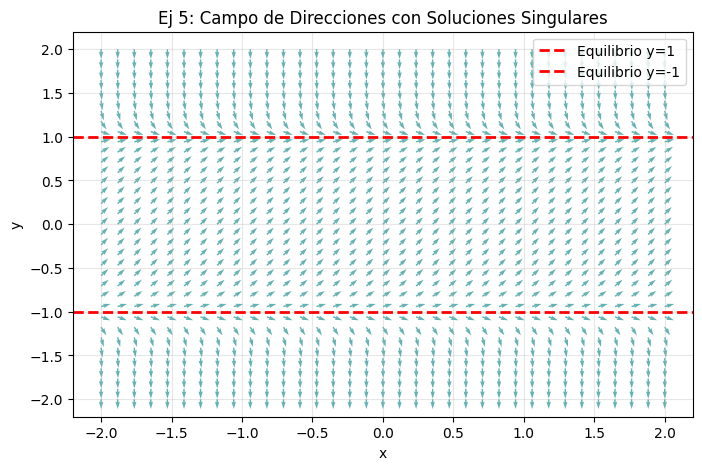

In [36]:
f6 = lambda x, y: np.exp(y**2) * (1 - y**2)
graficar_campo_direcciones(f6, [-2, 2], [-2, 2], "Ej 5: Campo de Direcciones con Soluciones Singulares", equilibrios=[1, -1], x_label='x', y_label='y')

#Ejercicio 7

La siguiente ecuación diferencial
$$ y' = e^{-x^2} $$
es separable y su solución general está dada por
$$ y = \int e^{-x^2} dx $$
pero la función $f(x)= e^{-x^2}$ no tiene primitiva, por ende no es posible determinar una solución explícita. A pesar de lo anterior, es posible ver el comportamiento gráfico de la solución.

* a) Construya un campo de direcciones asociado a la EDO.

* b) Determine (si es posible) el comportamiento de $y$ cuando $x \to \infty$, para la condición inicial $y(3)=0$.

* c) Justifique si la solución que pasa por $(3,0)$ es una función acotada.

    * **Hint:** Recuerde que: Una función $f:I \subset \mathbb{R} \to \mathbb{R}$ se dice acotada, si existe $M > 0$ tal que
$ |f(x)|< M , \quad \forall x \in I.  $

* d) A partir del campo de direcciones, justifique si existe alguna solución constante.

EDO: $y' = e^{-x^2} \quad ; \quad y(3) = 0$  
b) Comportamiento cuando $x \to \infty$: Como $e^{-x^2} > 0$, la función es siempre estrictamente creciente.  Al integrar, $y(x) = \int_3^x e^{-t^2} dt$. Cuando $x \to \infty$, esta integral converge a un valor constante finito positivo $\left(\approx \frac{\sqrt{\pi}}{2} - \int_0^3 e^{-t^2}dt \right)$. Es decir, $y$ tiende asintóticamente a un tope horizontal.  
c) ¿Es acotada?  Sí, es acotada. $y(x)$ arranca en $0$ y siempre crece pero su derivada decae tan rápido que el área bajo la curva $e^{-x^2}$ es finita. Su máximo absoluto se alcanza en el límite $x \to \infty$.  
d) ¿Soluciones constantes?No, no existe ninguna solución constante.  Para que exista, debe haber un $y$ tal que $y' = 0$, pero $e^{-x^2}$ jamás es cero para ningún $x \in \mathbb{R}$.

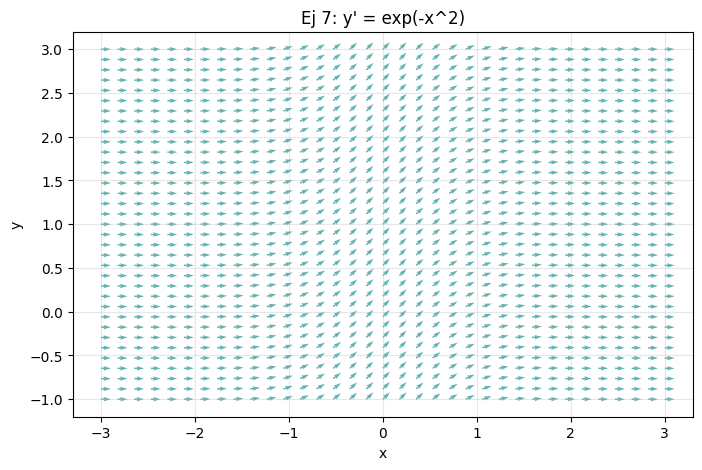

In [37]:
f7 = lambda x, y: np.exp(-x**2)
graficar_campo_direcciones(f7, [-3, 3], [-1, 3], "Ej 7: y' = exp(-x^2)")

#Ejercicio 8
Usando comando `dsolve` resuelva las siguientes EDOs:

* $y' =  \left( \dfrac{y}{x} \right)  + \ln \left( \dfrac{y}{x} \right)$
* $(y-\tan y \cos^2 x)dx + \left( \sin x \cos x - x \dfrac{\cos^2 x}{\cos^2 y} \right) dy = 0$
* $\sin x - x \cos x - 3x^2 (y-x)^2+3x^2(y-x)^2 y' = 0 \quad ; \quad y(1)=\sqrt{3}$

In [18]:
x = sp.Symbol('x', real=True)
y = sp.Function('y')(x)

# Ejercicio 8.1
eq8_1 = sp.Eq(y.diff(x), (y/x) + sp.log(y/x))
sol8_1 = sp.dsolve(eq8_1)
display("Solución 8.1:", sol8_1)

# Ejercicio 8.2
# (y - tan(y)*cos(x)^2)dx + (sin(x)cos(x) - x*cos(x)^2/cos(y)^2)dy = 0
# y' = -M/N
M = y - sp.tan(y)*sp.cos(x)**2
N = sp.sin(x)*sp.cos(x) - x*(sp.cos(x)**2 / sp.cos(y)**2)
eq8_2 = sp.Eq(y.diff(x), -M/N)
sol8_2 = sp.dsolve(eq8_2)
display("Solución 8.2:", sol8_2)

# Ejercicio 8.3
# sin(x) - x*cos(x) - 3x^2(y-x)^2 + 3x^2(y-x)^2 * y' = 0 ; y(1) = sqrt(3)
eq8_3 = sp.Eq(sp.sin(x) - x*sp.cos(x) - 3*x**2*(y-x)**2 + 3*x**2*(y-x)**2 * y.diff(x), 0)
sol8_3 = sp.dsolve(eq8_3, ics={y.subs(x, 1): sp.sqrt(3)})
display("Solución 8.3:", sol8_3)

'Solución 8.1:'

                ⎛y(x)⎞
log(x) = C₁ + li⎜────⎟
                ⎝ x  ⎠

KeyboardInterrupt: 

#Ejercicio 9

Considere la ecuación diferencial:

$$dx + \dfrac{1}{y}\left( \sqrt{x^2+y^2}-x\right) dy =0$$

* (a) Muestre que $\mu(x,y) = \frac{1}{\sqrt{x^2+y^2}}$ es un factor integrante de la EDO.
* (b) Resuelva la ecuación diferencial.

In [ ]:
# dx + (1/y)*(sqrt(x^2+y^2) - x)dy = 0
eq9 = sp.Eq(x.diff(y), -(1/y)*(sp.sqrt(x**2 + y**2) - x))

y_sym = sp.Symbol('y', positive=True)
x_fun = sp.Function('x')(y_sym)
eq9_formato = sp.Eq(x_fun.diff(y_sym) + (1/y_sym)*(sp.sqrt(x_fun**2 + y_sym**2) - x_fun), 0)
sol9 = sp.dsolve(eq9_formato)
display("Solución Ejercicio 9:", sol9)

'Solución Ejercicio 9:'

x(y) = y⋅sinh(C₁ - log(y))

#Ejercicio 10

Considere la EDO

$$y'=\tan^2(y)-\csc^2(y)-3$$

* (a) Encuentre todas las soluciones estacionarias de la EDO autónoma
* (b) Construya un campo de direcciones para la EDO en la región $D=[-2\pi , 2\pi]\times[-2\pi , 2\pi]$ grafique las soluciones estacionarias sobre el campo y clasifique los puntos en atractor, repulsor o nodo.
* (c) Sin resolver la EDO, justifique el valor de $\displaystyle\lim_{x \to \infty} y(x)$ para una solución que pase por $y(\pi)=\pi$.

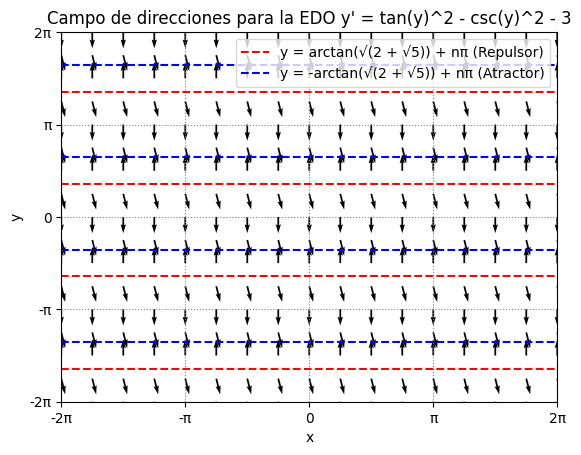

In [49]:
f10 = lambda x, y: np.tan(y)**2 - 1/np.sin(x)**2 - 3
    
X, Y = np.meshgrid(np.arange(-2*np.pi, 2*np.pi + 0.01, np.pi / 4), np.arange(-2*np.pi, 2*np.pi + 0.01, np.pi / 4))

U = 1.0
V = np.tan(Y)**2 - (np.sin(Y) + 1e-12)**-2 - 3

N = np.sqrt(U**2 + V**2)
U = U / N
V = V / N

plt.quiver(X, Y, U, V)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Campo de direcciones para la EDO y\' = tan(y)^2 - csc(y)^2 - 3')
plt.xlim(-2*np.pi, 2*np.pi)
plt.ylim(-2*np.pi, 2*np.pi)
plt.yticks(np.arange(-2*np.pi, 2*np.pi + 1, np.pi), labels=['-2π', '-π', '0', 'π', '2π'])
plt.xticks(np.arange(-2*np.pi, 2*np.pi + 1, np.pi), labels=['-2π', '-π', '0', 'π', '2π'])

y_eq_base = np.arctan(np.sqrt(2 + np.sqrt(5)))

for n in range(-3, 4):
    y1 = y_eq_base + n * np.pi
    y2 = -y_eq_base + n * np.pi
    
    if -2*np.pi <= y1 <= 2*np.pi:
        plt.axhline(y1, color='red', linestyle='--', linewidth=1.5, label='y = arctan(√(2 + √5)) + nπ (Repulsor)' if n == 0 else "")
    if -2*np.pi <= y2 <= 2*np.pi:
        plt.axhline(y2, color='blue', linestyle='--', linewidth=1.5, label='y = -arctan(√(2 + √5)) + nπ (Atractor)' if n == 0 else "")

plt.grid(True, linestyle=':', color='gray')
plt.legend(loc='upper right')
plt.show()